## 📓 Notebook Fine-Tuning YOLO - Vos Images Parking

In [1]:
from ultralytics import YOLO
import torch
from pathlib import Path
import shutil

print('✅ Imports OK')

✅ Imports OK


## Cellule 2 - Configuration

In [2]:
# Paths
DATASET_DIR = Path('Data/parking_vehicles')  # Votre dataset Roboflow
MODELS_DIR = Path('models/yolo_parking_finetuned')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Vérifier structure
yaml_file = DATASET_DIR / 'data.yaml'
print(f'📁 Dataset: {DATASET_DIR}')
print(f'📄 Config YAML: {yaml_file}')
print(f'✅ YAML existe: {yaml_file.exists()}')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

📁 Dataset: Data/parking_vehicles
📄 Config YAML: Data/parking_vehicles/data.yaml
✅ YAML existe: True

🖥️  Device: cuda
   GPU: NVIDIA GeForce RTX 4060 Laptop GPU


##  Cellule 3 - Vérifier Dataset

In [4]:
# Compter images
train_images = list((DATASET_DIR / 'train' / 'images').glob('*.*'))
valid_images = list((DATASET_DIR / 'valid' / 'images').glob('*.*'))
test_images = list((DATASET_DIR / 'test' / 'images').glob('*.*')) if (DATASET_DIR / 'test').exists() else []

print('📊 Dataset Stats:')
print(f'   Train: {len(train_images)} images')
print(f'   Valid: {len(valid_images)} images')
print(f'   Test: {len(test_images)} images')
print(f'   Total: {len(train_images) + len(valid_images) + len(test_images)}')

📊 Dataset Stats:
   Train: 102 images
   Valid: 29 images
   Test: 15 images
   Total: 146


##  Cellule 4 - Charger YOLO COCO (Base)

In [5]:
# Charger YOLO COCO pré-entraîné (base pour fine-tuning)
print('📦 Chargement YOLOv8n COCO (base)...')
model = YOLO('yolov8n.pt')  # Pré-entraîné COCO

print('✅ YOLOv8n chargé')
print('   Classes COCO: 80 (dont car, truck, bus)')
print('   On va fine-tuner sur VOS images parking!')

📦 Chargement YOLOv8n COCO (base)...
✅ YOLOv8n chargé
   Classes COCO: 80 (dont car, truck, bus)
   On va fine-tuner sur VOS images parking!


##  Cellule 5 - Configuration Fine-Tuning

In [6]:
# Config fine-tuning
CONFIG = {
    'data': str(yaml_file),
    'epochs': 30,           # 30 epochs suffisant pour fine-tuning
    'imgsz': 640,
    'batch': 16,
    'patience': 10,
    'device': 0 if torch.cuda.is_available() else 'cpu',
    'workers': 4,
    'project': str(MODELS_DIR),
    'name': 'parking_detector',
    'exist_ok': True,
    'pretrained': True,     # IMPORTANT: partir du modèle COCO
    'verbose': True,
    'plots': True,
    'save': True,
    'save_period': 5,
}

print('⚙️  Configuration Fine-Tuning:')
for key, value in CONFIG.items():
    print(f'   {key}: {value}')

⚙️  Configuration Fine-Tuning:
   data: Data/parking_vehicles/data.yaml
   epochs: 30
   imgsz: 640
   batch: 16
   patience: 10
   device: 0
   workers: 4
   project: models/yolo_parking_finetuned
   name: parking_detector
   exist_ok: True
   pretrained: True
   verbose: True
   plots: True
   save: True
   save_period: 5


##  Cellule 6 - FINE-TUNING 🚀

In [7]:
print('='*60)
print('🚀 DÉMARRAGE FINE-TUNING YOLO')
print('='*60)
print('\n⏱️  Durée estimée: 15-20 min')
print('📊 Transfer Learning: YOLO COCO → Parking Vehicles\n')

# LANCER FINE-TUNING
results = model.train(**CONFIG)

print('\n' + '='*60)
print('🎉 FINE-TUNING TERMINÉ!')
print('='*60)

🚀 DÉMARRAGE FINE-TUNING YOLO

⏱️  Durée estimée: 15-20 min
📊 Transfer Learning: YOLO COCO → Parking Vehicles

New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Data/parking_vehicles/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01,

##  Cellule 7 - Validation

In [8]:
# Valider modèle fine-tuné
print('📊 Validation du modèle fine-tuné...\n')

metrics = model.val(
    data=str(yaml_file),
    imgsz=640,
    batch=16,
    conf=0.25,
)

print('\n' + '='*60)
print('📊 MÉTRIQUES FINALES')
print('='*60)
print(f'mAP50: {metrics.box.map50:.4f}')
print(f'mAP50-95: {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall: {metrics.box.mr:.4f}')
print('='*60)

📊 Validation du modèle fine-tuné...

Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.2±0.3 ms, read: 15.1±3.4 MB/s, size: 52.5 KB)
val: Scanning /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/Data/parking_vehicles/valid/labels.cache... 29 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 8.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5s/it 4.9s<14.4s
                   all         29         30          1      0.867      0.933      0.791
Speed: 15.8ms preprocess, 18.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/runs/detect/val4

📊 MÉTRIQUES FINALES
mAP50: 0.9333
mAP50-95: 0.7915
Pre

##  Cellule 8 - Tester sur Vos Images Problématiques

✅ Meilleur modèle chargé: runs/detect/models/yolo_parking_finetuned/parking_detector/weights/best.pt


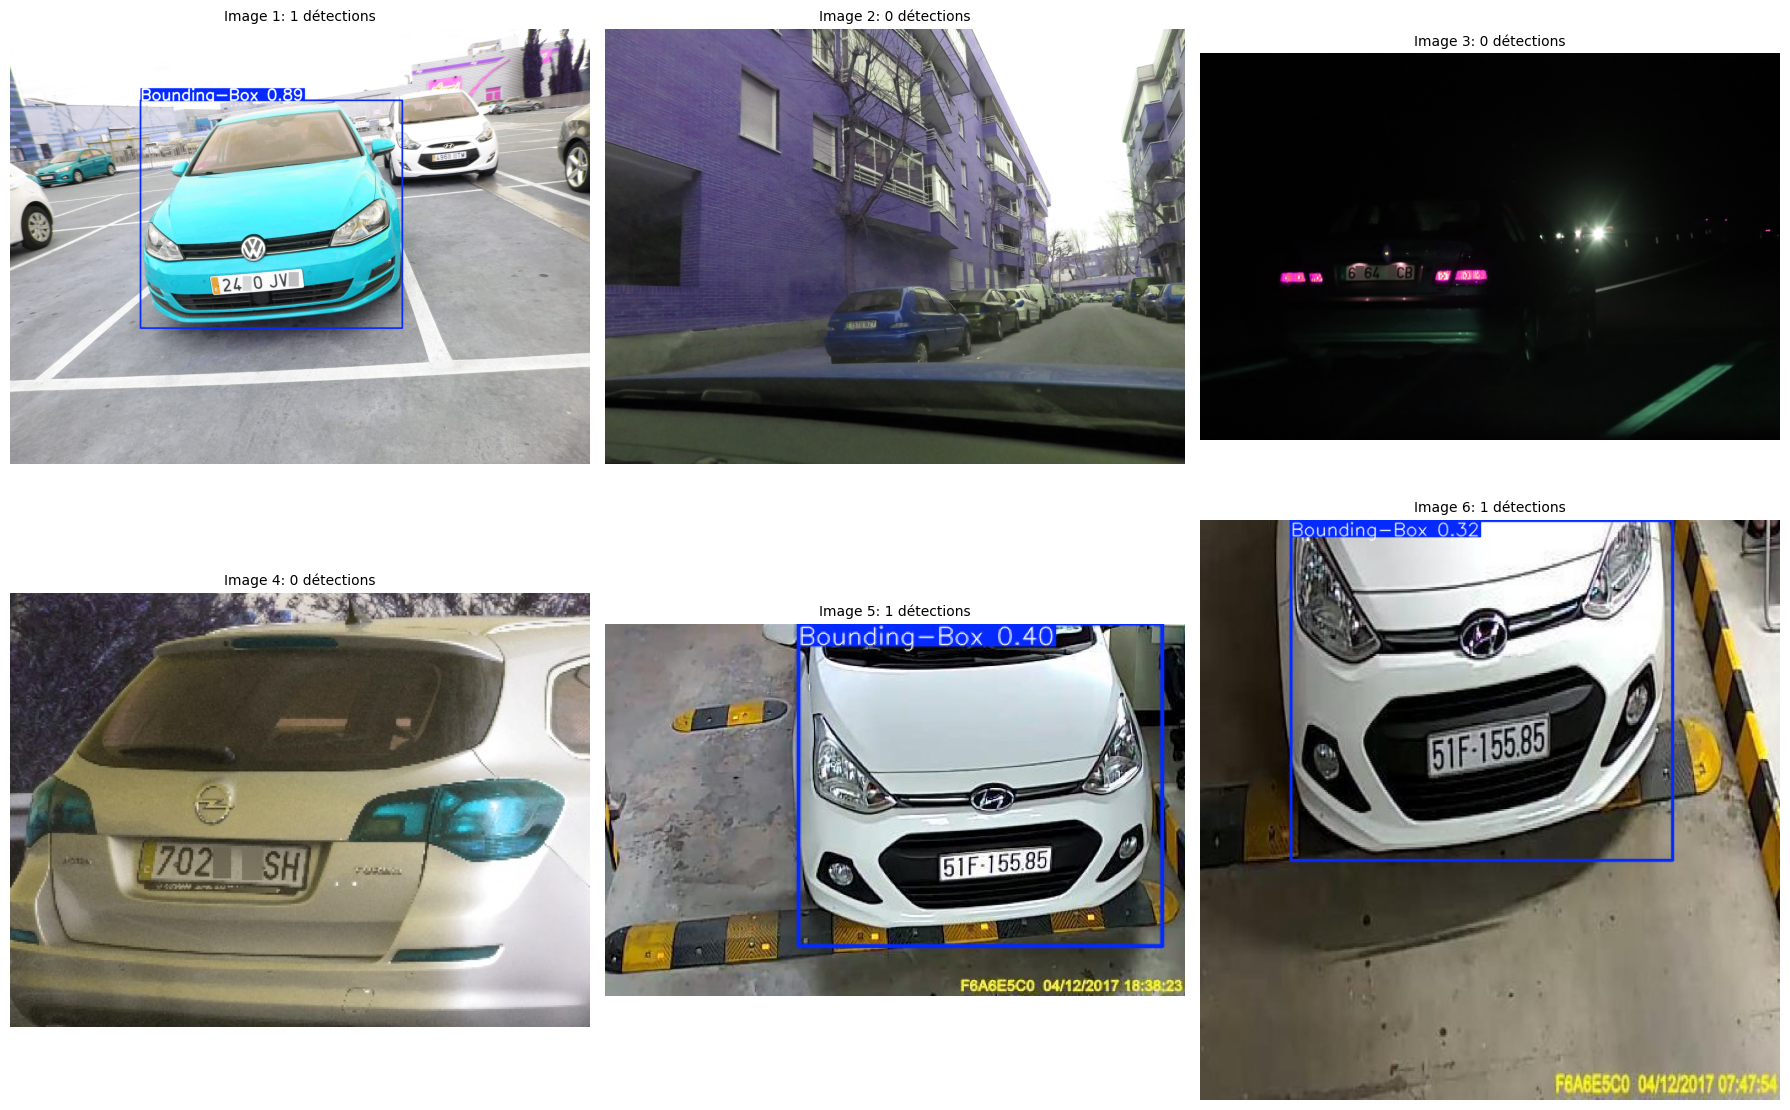


🎯 Comparez avec les résultats précédents!
   Devrait être BEAUCOUP mieux maintenant!


In [17]:
%matplotlib inline

# Charger meilleur modèle
best_model_path = Path('runs/detect/models/yolo_parking_finetuned/parking_detector/weights/best.pt')
best_model = YOLO(str(best_model_path))

print(f'✅ Meilleur modèle chargé: {best_model_path}')

# TESTEZ sur vos 6 images qui échouaient avant!
test_images_paths = [
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/00026.jpg',  # VW Golf
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/00064.jpg',  # Mitsubishi immeuble
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/00427.jpg',  # Nuit
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/01016.jpg',  # Bus
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/10013.jpg',  # Audi
    '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/sample/CarLongPlate8_jpg.rf.d838c4ae3e9e205ce1edc54bc0c38376.jpg',  # Dodge
]

import matplotlib.pyplot as plt
import cv2

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, img_path in enumerate(test_images_paths):
    if not Path(img_path).exists():
        continue
        
    results = best_model(img_path, conf=0.25, verbose=False)
    
    img_annotated = results[0].plot()
    img_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_rgb)
    n_det = len(results[0].boxes)
    axes[idx].set_title(f'Image {idx+1}: {n_det} détections', fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print('\n🎯 Comparez avec les résultats précédents!')
print('   Devrait être BEAUCOUP mieux maintenant!')